In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from pathlib import Path

# Resolve project root relative to this notebook (notebooks/ -> parent = hw1/)
PROJECT_ROOT = Path(".").resolve().parent
DATA_DIR    = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_excel(DATA_DIR / "titanic3.xls")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [3]:
df = df.drop_duplicates()

In [4]:
df = df.drop(columns=['name', 'ticket'])

In [5]:
column_nan_count = df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
pclass          0
survived        0
sex             0
age           263
sibsp           0
parch           0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64


In [6]:
df = df.loc[:, df.isnull().mean() <= 0.30]

In [7]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(df[num_cols])
print(df[cat_cols])

      pclass  survived      age  sibsp  parch      fare
0          1         1  29.0000      0      0  211.3375
1          1         1   0.9167      1      2  151.5500
2          1         0   2.0000      1      2  151.5500
3          1         0  30.0000      1      2  151.5500
4          1         0  25.0000      1      2  151.5500
...      ...       ...      ...    ...    ...       ...
1304       3         0  14.5000      1      0   14.4542
1305       3         0      NaN      1      0   14.4542
1306       3         0  26.5000      0      0    7.2250
1307       3         0  27.0000      0      0    7.2250
1308       3         0  29.0000      0      0    7.8750

[1309 rows x 6 columns]
         sex embarked
0     female        S
1       male        S
2     female        S
3       male        S
4     female        S
...      ...      ...
1304  female        C
1305  female        C
1306    male        C
1307    male        C
1308    male        S

[1309 rows x 2 columns]


In [8]:
df[num_cols].describe()

,pclass,survived,age,sibsp,parch,fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   fare      1308 non-null   float64
 7   embarked  1307 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 81.9+ KB


In [10]:
column_nan_count = df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
pclass        0
survived      0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64


In [11]:
# %%
for col in cat_cols:
    print(f"{col.upper()}")
    print(df[col].value_counts(dropna=False))
    print("\n")

SEX
sex
male      843
female    466
Name: count, dtype: int64


EMBARKED
embarked
S      914
C      270
Q      123
NaN      2
Name: count, dtype: int64




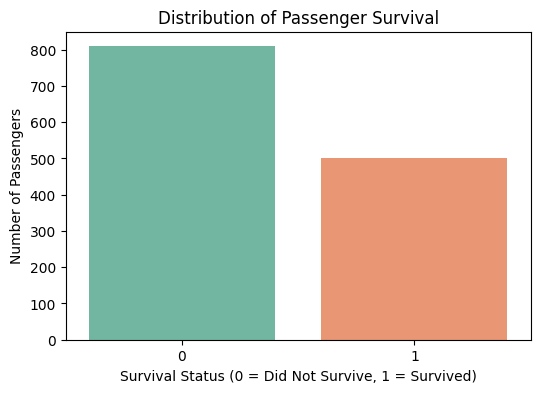

In [12]:
plt.figure(figsize=(6, 4))


sns.countplot(data=df, x='survived', hue='survived', palette='Set2', legend=False)

plt.title('Distribution of Passenger Survival')
plt.xlabel('Survival Status (0 = Did Not Survive, 1 = Survived)')
plt.ylabel('Number of Passengers')

plt.savefig(FIGURES_DIR / 'survival_distribution.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [13]:
survival_proportions = df['survived'].value_counts(normalize=True).round(2)
print(survival_proportions)

survived
0    0.62
1    0.38
Name: proportion, dtype: float64


The dataset is mildly imbalanced, with 62% of passengers not surviving (0) and 38% surviving (1), a ratio insufficient to be considered severe but notable enough to affect model evaluation

# =====================================================================
# INVESTIGATION 1: SEX (Categorical -> Bar Plot)
# =====================================================================

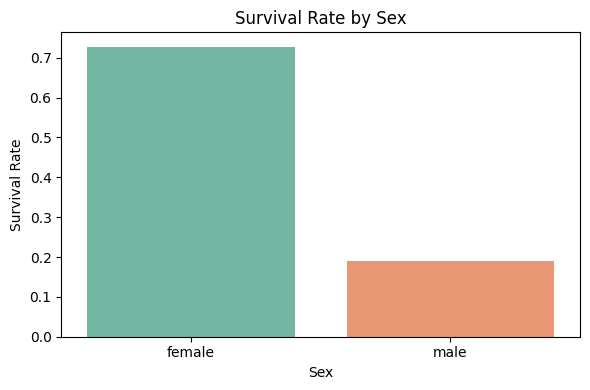

In [14]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df, 
    x='sex', 
    y='survived', 
    hue='sex', 
    errorbar=None, 
    palette='Set2'
)

plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'Survival_Rate_by_Sex.pdf', dpi=300, bbox_inches='tight')
plt.show()

I observe that female passengers had a significantly higher survival rate, reaching over 70%, whereas male passengers had a much lower survival rate of under 20%.

# =====================================================================
# INVESTIGATION 2: PCLASS (Categorical -> Bar Plot)
# =====================================================================

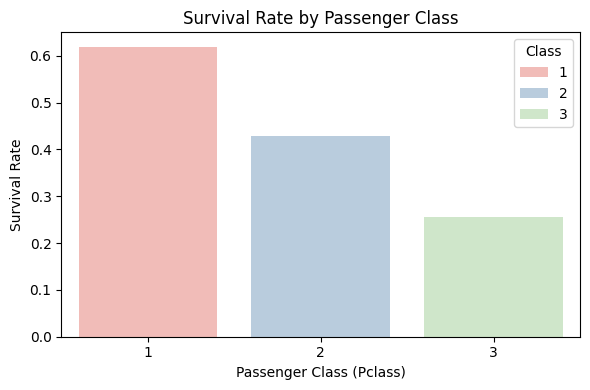

In [15]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df, 
    x='pclass', 
    y='survived', 
    hue='pclass', 
    errorbar=None, 
    palette='Pastel1'
)

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (Pclass)')
plt.ylabel('Survival Rate')
plt.legend(title='Class')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'Survival_Rate_by_Passenger_Class.pdf', dpi=300, bbox_inches='tight')
plt.show()

I observe that the survival rate was highest for first-class passengers (Class 1) and decreased steadily with each subsequent class, leaving third-class passengers (Class 3) with the lowest probability of survival.

# =====================================================================
# INVESTIGATION 3: AGE (Continuous -> KDE Plot grouped by Survival)
# =====================================================================

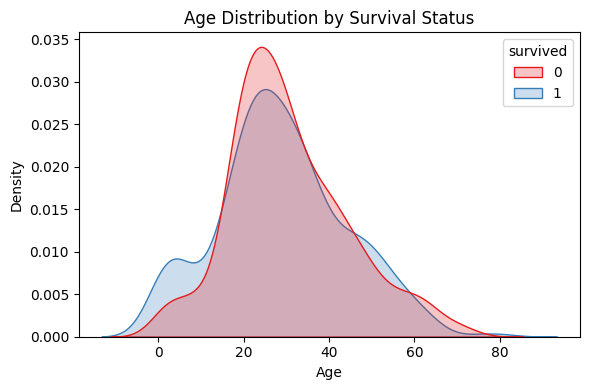

In [16]:
plt.figure(figsize=(6, 4))


sns.kdeplot(
    data=df, 
    x='age', 
    hue='survived', 
    fill=True, 
    common_norm=False, 
    palette='Set1'
)

plt.title('Age Distribution by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'Age_Distribution_by_Survival_Status.pdf', dpi=300, bbox_inches='tight')
plt.show()

I observe that the age distributions for both survivors and non-survivors heavily overlap across most age groups, though a small spike in density at the lower end indicates that very young children had a slightly higher probability of survival.

In [17]:
column_nan_count = df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
pclass        0
survived      0
sex           0
age         263
sibsp         0
parch         0
fare          1
embarked      2
dtype: int64


| Column   | % Missing | Strategy         | Justification                          |
|----------|-----------|------------------|----------------------------------------|
| age      | ~20%      | Median imputation| Right-skewed distribution (skew > 0.5) |
| fare     | <1%       | Median imputation| Right-skewed distribution              |
| embarked | <1%       | Mode imputation  | Categorical — most frequent class      |
| boat, body, home.dest | >30% | Dropped | Missingness exceeds 30% threshold     |

In [18]:
skew_vals = df[num_cols].skew()
for col in num_cols:
    # Use median if data is skewed, otherwise use mean
    if abs(skew_vals[col]) > 0.5:
        fill_val = df[col].median()
    else:
        fill_val = df[col].mean()
    
    df[col] = df[col].fillna(fill_val)

In [19]:
for col in cat_cols:
    fill_val = df[col].mode()[0]
    df[col] = df[col].fillna(fill_val)

In [20]:
column_nan_count = df.isnull().sum()
print("NaN count per column ")
print(column_nan_count)

NaN count per column 
pclass      0
survived    0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   object 
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   fare      1309 non-null   float64
 7   embarked  1309 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 81.9+ KB


In [22]:
# Force get_dummies to create 0 and 1 instead of True and False
df = pd.get_dummies(df, columns=['sex', 'embarked'], dtype=int)

In [23]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pclass      1309 non-null   int64  
 1   survived    1309 non-null   int64  
 2   age         1309 non-null   float64
 3   sibsp       1309 non-null   int64  
 4   parch       1309 non-null   int64  
 5   fare        1309 non-null   float64
 6   sex_female  1309 non-null   int64  
 7   sex_male    1309 non-null   int64  
 8   embarked_C  1309 non-null   int64  
 9   embarked_Q  1309 non-null   int64  
 10  embarked_S  1309 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 112.6 KB


,pclass,survived,age,sibsp,parch,fare,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,1,1,29.0000,0,0,211.3375,1,0,0,0,1
1,1,1,0.9167,1,2,151.5500,0,1,0,0,1
2,1,0,2.0000,1,2,151.5500,1,0,0,0,1
3,1,0,30.0000,1,2,151.5500,0,1,0,0,1
4,1,0,25.0000,1,2,151.5500,1,0,0,0,1


In [24]:
feature_cols = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']
X = df[feature_cols].astype(float).to_numpy()

In [25]:
y = df['survived'].to_numpy()

In [26]:
N, p = X.shape
print(f"Dataset ready: N={N} rows (samples), p={p} columns (features)")

Dataset ready: N=1309 rows (samples), p=10 columns (features)


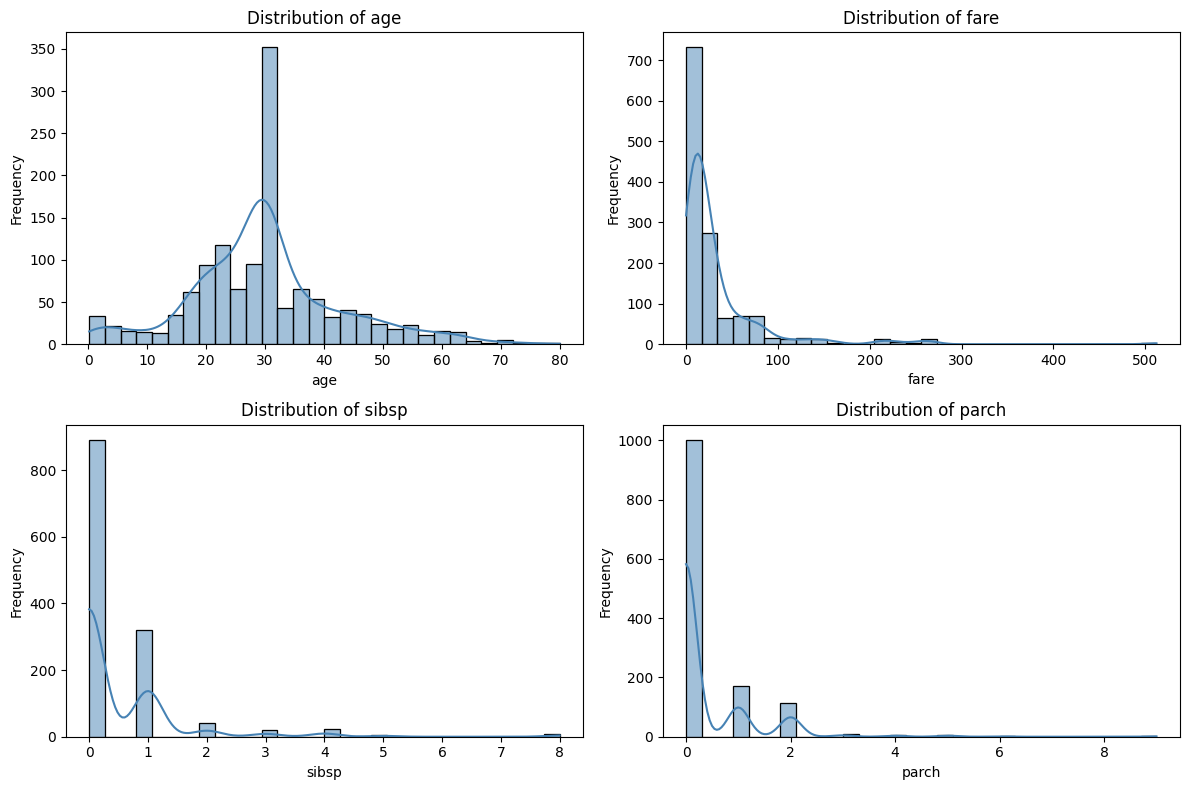

In [27]:
# %%
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical columns we want to inspect
continuous_cols = ['age', 'fare', 'sibsp', 'parch']

# Set up a grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    # Plot histogram with a smooth KDE line
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [28]:
from scipy import stats
import numpy as np

# age — z-score (near-normal)
df = df[np.abs(stats.zscore(df['age'].dropna())) < 3]

# fare — IQR (right-skewed)
Q1, Q3 = df['fare'].quantile([0.25, 0.75])
IQR = Q3 - Q1
df = df[(df['fare'] >= Q1 - 1.5 * IQR) & (df['fare'] <= Q3 + 1.5 * IQR)]

# sibsp & parch — percentile cap (zero-inflated counts)
for col in ['sibsp', 'parch']:
    cap = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=cap)

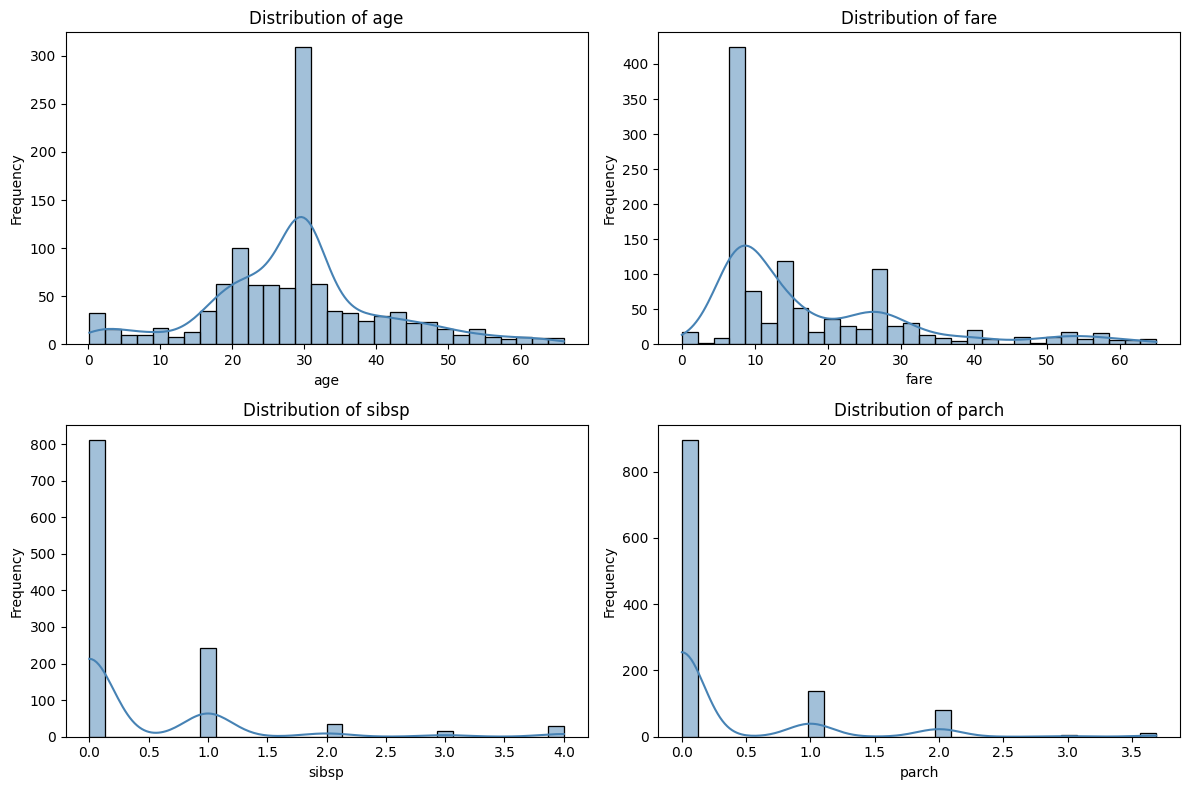

In [29]:
# %%
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical columns we want to inspect
continuous_cols = ['age', 'fare', 'sibsp', 'parch']

# Set up a grid of plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    # Plot histogram with a smooth KDE line
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='steelblue', bins=30)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [30]:
# --- Save cleaned feature matrix for use in later notebooks ---
import pandas as pd

df_out = pd.DataFrame(X, columns=feature_cols)
df_out["survived"] = y

DATA_DIR.mkdir(exist_ok=True)
out_path = DATA_DIR / "titanic_cleaned.csv"
df_out.to_csv(out_path, index=False)

print(f"Saved cleaned dataset to: {out_path}")
print(f"Shape: {df_out.shape}")
print(df_out.head())


Saved cleaned dataset to: C:\Users\Emil\Desktop\Subjects\AI Academy\AI Engineering\Machine Learning\Homeworks\hw1\data\titanic_cleaned.csv
Shape: (1309, 11)
   pclass      age  sibsp  parch      fare  sex_female  sex_male  embarked_C  \
0     1.0  29.0000    0.0    0.0  211.3375         1.0       0.0         0.0   
1     1.0   0.9167    1.0    2.0  151.5500         0.0       1.0         0.0   
2     1.0   2.0000    1.0    2.0  151.5500         1.0       0.0         0.0   
3     1.0  30.0000    1.0    2.0  151.5500         0.0       1.0         0.0   
4     1.0  25.0000    1.0    2.0  151.5500         1.0       0.0         0.0   

   embarked_Q  embarked_S  survived  
0         0.0         1.0         1  
1         0.0         1.0         1  
2         0.0         1.0         0  
3         0.0         1.0         0  
4         0.0         1.0         0  
